# 🕸️ Graph Neural Networks — เรียนรู้จาก "ความเชื่อมโยง"

Notebook **เล่มที่ 6** — สถาปัตยกรรมสำหรับข้อมูลที่เป็น **กราฟ (graph)**: จุด (node) ที่เชื่อมกันด้วยเส้น (edge)

โมเดลทุกตัวที่ผ่านมารับข้อมูลที่มี "รูปทรงคงที่" — ตาราง (เล่ม 3), ภาพ grid (CNN), ลำดับ (transformer)
แต่ข้อมูลจำนวนมากในโลกจริงเป็น **กราฟ**: เครือข่ายคอมพิวเตอร์, โซเชียล, โมเลกุล, แผนที่, เว็บ
ความหมายของแต่ละ node ขึ้นกับ **"มันเชื่อมกับใคร"** ไม่ใช่แค่ feature ของตัวเอง

| Part | เนื้อหา | สร้างเอง |
|---|---|---|
| 1 | Graph คืออะไร + ทำไม ML ปกติไม่พอ | networkx |
| 2 | **Message Passing** — หัวใจของ GNN | NumPy ล้วน |
| 3 | **GCN** — จำแนก node กึ่ง supervised (Karate Club) | TensorFlow |
| 4 | **ตรวจจับ botnet จากโครงสร้างกราฟ** (security) | TensorFlow |
| 5 | Over-smoothing + ประเภทงานของ GNN | NumPy |
| 6 | ของจริง + สรุปทั้ง 6 เล่ม | — |

> **หัวใจของ GNN:** ให้แต่ละ node "คุย" กับเพื่อนบ้าน ดูดข้อมูลมารวมกับของตัวเอง แล้วอัปเดตตัวแทนของตัวเอง
> ทำซ้ำหลายชั้น → node รับรู้บริบทไกลขึ้นเรื่อย ๆ (1 ชั้น = เพื่อนบ้าน, 2 ชั้น = เพื่อนของเพื่อน, ...)
> เล่ม 3 มอง traffic **ทีละ flow** แต่ GNN มอง **โครงสร้างการเชื่อมต่อทั้งภาพ** — เห็นสิ่งที่ดูทีละเส้นไม่เห็น

In [1]:
# ── Setup ──
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel("ERROR")

plt.rcParams["font.family"] = "Tahoma"          # ฟอนต์อักษรไทยสำหรับ plot
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(0)

---
## Part 1 — Graph คืออะไร และทำไม ML ปกติถึงไม่พอ

**กราฟ** ประกอบด้วย:
- **Node** (จุด) — เช่น เครื่องคอมพิวเตอร์, คน, อะตอม
- **Edge** (เส้น) — ความสัมพันธ์ระหว่าง node เช่น "เชื่อมต่อกัน", "เป็นเพื่อนกัน"
- **Node features** (ไม่บังคับ) — คุณสมบัติของแต่ละ node

แทนการเชื่อมต่อด้วย **adjacency matrix** $A$ ขนาด $N \times N$: $A_{ij}=1$ ถ้า node $i$ ต่อกับ node $j$

**ทำไม ML ปกติไม่พอ?** โมเดลทั่วไปสมมติว่าข้อมูลแต่ละชิ้น "เป็นอิสระต่อกัน" (i.i.d.) — ดูทีละแถวได้เลย
แต่ในกราฟ node **ไม่อิสระ** — มันนิยามตัวเองผ่านเพื่อนบ้าน ถ้าดู feature ทีละ node โดยไม่สนการเชื่อมต่อ ก็ทิ้งข้อมูลสำคัญที่สุดไป

Adjacency matrix (แถว/คอลัมน์ = node 0..5):
[[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]


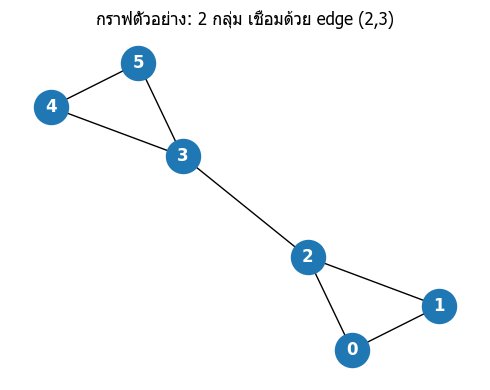

In [2]:
# ── สร้างกราฟตัวอย่างเล็ก ๆ: 2 กลุ่มที่เชื่อมกันด้วยสะพานเส้นเดียว ──
edges = [(0,1),(1,2),(0,2),      # กลุ่ม A: สามเหลี่ยม {0,1,2}
         (3,4),(4,5),(3,5),      # กลุ่ม B: สามเหลี่ยม {3,4,5}
         (2,3)]                  # สะพานเชื่อม 2 กลุ่ม
G = nx.Graph(edges)
A = nx.to_numpy_array(G, nodelist=range(6))

print("Adjacency matrix (แถว/คอลัมน์ = node 0..5):")
print(A.astype(int))

fig, ax = plt.subplots(figsize=(5, 4))
pos = nx.spring_layout(G, seed=2)
nx.draw(G, pos, with_labels=True, node_color="tab:blue", node_size=600,
        font_color="white", font_weight="bold", ax=ax)
ax.set_title("กราฟตัวอย่าง: 2 กลุ่ม เชื่อมด้วย edge (2,3)")
plt.tight_layout(); plt.show()

---
## Part 2 — Message Passing: หัวใจของ GNN

ไอเดียเดียวที่ขับเคลื่อน GNN ทั้งหมด — **แต่ละ node อัปเดตตัวเองจากเพื่อนบ้าน** ผ่าน 3 ขั้น:

1. **Message** — เพื่อนบ้านแต่ละตัวส่งข้อมูล (feature ของมัน) มาให้
2. **Aggregate** — รวมข้อมูลจากเพื่อนบ้านทั้งหมด (เช่น เฉลี่ย)
3. **Update** — เอาที่รวมได้ไปปรับตัวแทนของ node

ทำทั้งกราฟพร้อมกันได้ด้วยการคูณ matrix ครั้งเดียว — สูตรของ **GCN** (Graph Convolutional Network):

$$H' = \sigma\!\left(\hat{A}\,H\,W\right)$$

- $H$ = feature ของทุก node (แถวละ node), $W$ = weight ที่เรียนรู้ได้, $\sigma$ = activation
- $\hat{A}$ = adjacency ที่ปรับแล้ว: $\hat{A} = \tilde{D}^{-1/2}(A+I)\,\tilde{D}^{-1/2}$
  - $+I$ = เพิ่ม self-loop (ให้ node เห็นตัวเองด้วย ไม่ใช่แค่เพื่อนบ้าน)
  - $\tilde{D}^{-1/2}(\cdots)\tilde{D}^{-1/2}$ = normalize ตาม degree (node ที่เพื่อนเยอะจะได้ไม่ครอบงำ)

ดูก่อนว่า "ข้อมูลแพร่" ผ่านกราฟยังไง — ปล่อยสัญญาณที่ node 0 แล้วดูมันกระจาย:

In [3]:
# ── message passing ด้วย NumPy: สัญญาณแพร่จาก node 0 ทีละชั้น ──
def normalize_adj(A):
    """A_hat = D^-1/2 (A+I) D^-1/2"""
    A_tilde = A + np.eye(A.shape[0])         # เพิ่ม self-loop
    deg = A_tilde.sum(1)
    Dinv = np.diag(1.0/np.sqrt(deg))         # normalize ตาม degree
    return Dinv @ A_tilde @ Dinv

A_hat = normalize_adj(A)

h = np.zeros((6, 1)); h[0] = 1.0             # ปล่อยสัญญาณไว้ที่ node 0 เท่านั้น
print("เริ่มต้น (สัญญาณอยู่ที่ node 0):", h.ravel().round(2))
for layer in range(1, 4):
    h = A_hat @ h                            # 1 รอบ message passing = แพร่ออกไป 1 hop
    print(f"หลังชั้นที่ {layer}:           ", h.ravel().round(2))
print("\n→ ชั้นที่ 1 สัญญาณไปถึงเพื่อนบ้านตรง (1,2) | ชั้นที่ 2 ไปถึงเพื่อนของเพื่อน (3) | ชั้นที่ 3 ทั่วทั้งกราฟ")
print("  นี่คือเหตุผลที่ 'จำนวนชั้น GNN' = 'มองได้ไกลกี่ hop'")

เริ่มต้น (สัญญาณอยู่ที่ node 0): [1. 0. 0. 0. 0. 0.]
หลังชั้นที่ 1:            [0.33 0.33 0.29 0.   0.   0.  ]
หลังชั้นที่ 2:            [0.31 0.31 0.26 0.07 0.   0.  ]
หลังชั้นที่ 3:            [0.28 0.28 0.26 0.08 0.02 0.02]

→ ชั้นที่ 1 สัญญาณไปถึงเพื่อนบ้านตรง (1,2) | ชั้นที่ 2 ไปถึงเพื่อนของเพื่อน (3) | ชั้นที่ 3 ทั่วทั้งกราฟ
  นี่คือเหตุผลที่ 'จำนวนชั้น GNN' = 'มองได้ไกลกี่ hop'


In [4]:
# ── 1 ชั้น GCN เต็ม ๆ (มี weight + activation) ──
def gcn_layer(A_hat, H, W):
    return np.maximum(0, A_hat @ H @ W)      # ReLU(A_hat @ H @ W)

# ลองให้ feature เริ่มต้นเป็น one-hot (identity) แล้วดูว่า node ในกลุ่มเดียวกันได้ค่าใกล้กัน
H0 = np.eye(6)
np.random.seed(1)
W = np.random.randn(6, 2)                     # weight สุ่ม (ของจริงเรียนรู้ผ่าน backprop)
H1 = gcn_layer(A_hat, H0, W)
H2 = gcn_layer(A_hat, H1, np.random.randn(2, 2))

print("ตัวแทน node หลัง 2 ชั้น GCN (สุ่ม weight):")
for i in range(6):
    grp = "A {0,1,2}" if i < 3 else "B {3,4,5}"
    print(f"  node {i} (กลุ่ม {grp}): {H2[i].round(3)}")
print("\n→ แม้ weight ยังสุ่ม node ในกลุ่มเดียวกันก็เริ่มได้ค่าคล้ายกัน เพราะแชร์เพื่อนบ้าน")
print("  พอ train จริง (Part 3) weight จะถูกปรับให้กลุ่มต่างกันแยกออกจากกันชัดเจน")

ตัวแทน node หลัง 2 ชั้น GCN (สุ่ม weight):
  node 0 (กลุ่ม A {0,1,2}): [0. 0.]
  node 1 (กลุ่ม A {0,1,2}): [0. 0.]
  node 2 (กลุ่ม A {0,1,2}): [0. 0.]
  node 3 (กลุ่ม B {3,4,5}): [0. 0.]
  node 4 (กลุ่ม B {3,4,5}): [0. 0.]
  node 5 (กลุ่ม B {3,4,5}): [0. 0.]

→ แม้ weight ยังสุ่ม node ในกลุ่มเดียวกันก็เริ่มได้ค่าคล้ายกัน เพราะแชร์เพื่อนบ้าน
  พอ train จริง (Part 3) weight จะถูกปรับให้กลุ่มต่างกันแยกออกจากกันชัดเจน


---
## Part 3 — GCN เต็มตัว: จำแนก Node แบบกึ่ง Supervised

ทดสอบกับ **Zachary's Karate Club** — กราฟสุดคลาสสิกของวงการ: สมาชิกชมรมคาราเต้ 34 คน
ที่ทะเลาะกันจนชมรมแตกเป็น 2 ฝ่าย (ฝ่ายอาจารย์ "Mr. Hi" กับฝ่ายประธาน "Officer")

โจทย์ **semi-supervised node classification**: เรารู้ฝ่ายของแค่ **2 คน** (หัวหน้าแต่ละฝ่าย)
แล้วให้ GCN ทำนายฝ่ายของอีก 32 คนที่เหลือ — **จากโครงสร้างการเชื่อมต่อล้วน ๆ** (ไม่มี feature อื่น)

นี่คือพลังของ GNN: label น้อยนิด แต่ "ความเชื่อมโยง" เติมเต็มข้อมูลที่ขาด

In [5]:
# ── train GCN 2 ชั้นบน Karate Club ──
def train_gcn(A_hat, X, labels, train_mask, n_classes, hidden=8, epochs=200, lr=0.02, seed=0):
    keras.utils.set_random_seed(seed)
    N, F = X.shape
    init = keras.initializers.GlorotUniform(seed=seed)
    W1 = tf.Variable(init((F, hidden)))                  # weight ชั้นที่ 1
    W2 = tf.Variable(init((hidden, n_classes)))          # weight ชั้นที่ 2
    A_hat = tf.constant(A_hat.astype("float32")); X = tf.constant(X.astype("float32"))
    y = tf.constant(labels); mask = tf.constant(train_mask)
    opt = keras.optimizers.Adam(lr)

    def forward():
        H = tf.nn.relu(A_hat @ X @ W1)                   # ชั้น 1: message passing + ReLU
        return H, A_hat @ H @ W2                         # ชั้น 2: ได้ logits ของแต่ละ node

    for ep in range(epochs):
        with tf.GradientTape() as tape:
            H, logits = forward()
            ce = tf.nn.sparse_softmax_cross_entropy_with_logits(y, logits)
            # คิด loss เฉพาะ node ที่มี label (semi-supervised)
            loss = tf.reduce_sum(ce * tf.cast(mask, tf.float32)) / tf.reduce_sum(tf.cast(mask, tf.float32))
        g = tape.gradient(loss, [W1, W2]); opt.apply_gradients(zip(g, [W1, W2]))

    H, logits = forward()
    return tf.argmax(logits, 1).numpy(), H.numpy()

G_k = nx.karate_club_graph()
A_k = nx.to_numpy_array(G_k)
labels = np.array([0 if G_k.nodes[i]["club"] == "Mr. Hi" else 1 for i in G_k.nodes])
X_k = np.eye(A_k.shape[0])                                # ไม่มี feature -> identity (เรียนจากโครงสร้าง)

train_mask = np.zeros(len(labels), bool)
train_mask[0] = True; train_mask[33] = True              # รู้ฝ่ายแค่ 2 หัวหน้า (node 0, 33)

pred, emb = train_gcn(normalize_adj(A_k), X_k, labels, train_mask, n_classes=2, hidden=4, epochs=200)
acc = (pred == labels).mean()
print(f"รู้ฝ่ายแค่ 2 คน → GCN ทำนายอีก 32 คนถูก {acc:.0%} (ทั้งกราฟ {(pred==labels).sum()}/34)")

รู้ฝ่ายแค่ 2 คน → GCN ทำนายอีก 32 คนถูก 97% (ทั้งกราฟ 33/34)


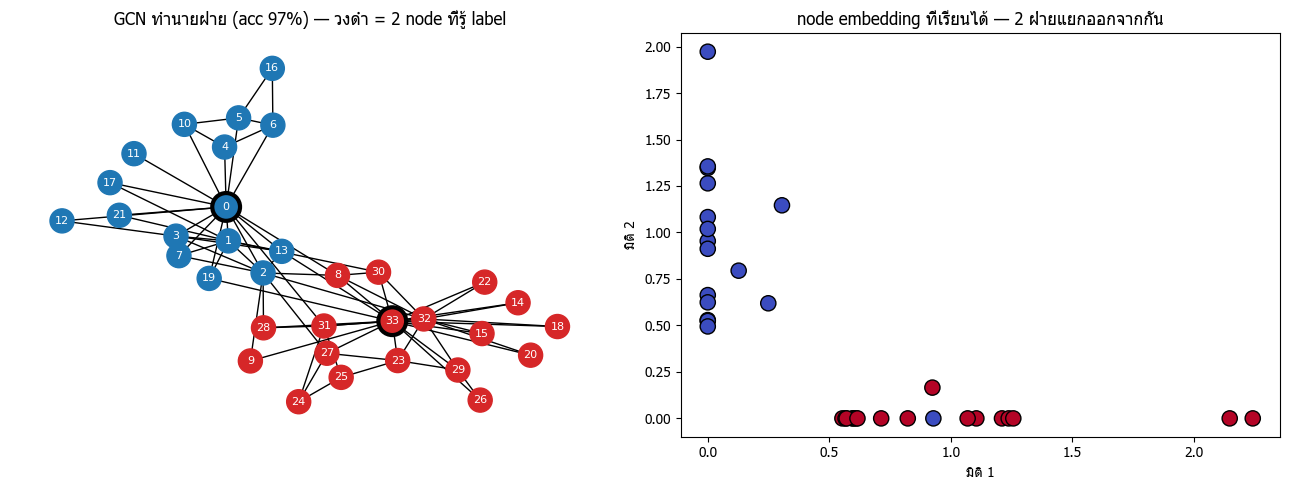

GCN เรียนรู้ว่า 'คนที่เชื่อมโยงกันหนาแน่น มักอยู่ฝ่ายเดียวกัน' — จาก label แค่ 2 จุด


In [6]:
# ── ดูผล: กราฟระบายสีตามคำทำนาย + node embedding ที่เรียนได้ ──
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
pos = nx.spring_layout(G_k, seed=1)
colors = ["tab:blue" if p == 0 else "tab:red" for p in pred]
# วงสีดำรอบ 2 node ที่เรารู้ label จริง
nx.draw(G_k, pos, node_color=colors, with_labels=True, node_size=300,
        font_size=8, font_color="white", ax=ax[0])
nx.draw_networkx_nodes(G_k, pos, nodelist=[0, 33], node_color="none",
                       edgecolors="black", linewidths=3, node_size=400, ax=ax[0])
ax[0].set_title(f"GCN ทำนายฝ่าย (acc {acc:.0%}) — วงดำ = 2 node ที่รู้ label")

ax[1].scatter(emb[:, 0], emb[:, 1], c=labels, cmap="coolwarm", s=120, edgecolors="k")
ax[1].set_title("node embedding ที่เรียนได้ — 2 ฝ่ายแยกออกจากกัน")
ax[1].set_xlabel("มิติ 1"); ax[1].set_ylabel("มิติ 2")
plt.tight_layout(); plt.show()
print("GCN เรียนรู้ว่า 'คนที่เชื่อมโยงกันหนาแน่น มักอยู่ฝ่ายเดียวกัน' — จาก label แค่ 2 จุด")

---
## Part 4 — ตรวจจับ Botnet จากโครงสร้างกราฟ (Security)

ต่อยอดเข้าธีม network security (เล่ม 3) — แต่คราวนี้มองที่ **โครงสร้างการเชื่อมต่อ** ไม่ใช่สถิติ flow

**Botnet** มีลายเซ็นเชิงโครงสร้างที่ชัดเจน: เครื่องที่ติดเชื้อมัก **คุยกันเองหนาแน่น** (รับคำสั่งประสานงานกัน)
และ **เชื่อมเข้า C2 server** ตัวเดียวกัน — กลายเป็น "กระจุกหนาแน่น" ที่ผิดธรรมชาติในกราฟ

การมอง traffic ทีละ flow อาจไม่เห็น เพราะแต่ละ flow ดูปกติ — แต่ **รูปแบบการเชื่อมต่อโดยรวม** แฉออกมา

เราจะให้ทุก node มี **feature เหมือนกันหมด** (identity) เพื่อบังคับให้ GNN ตัดสินจาก **โครงสร้างล้วน ๆ**

In [7]:
# ── สร้างเครือข่ายจำลอง: host ปกติ + botnet (clique หนาแน่น) + C2 ──
rng = np.random.default_rng(42)
N_benign, N_bot = 90, 18

Gn = nx.erdos_renyi_graph(N_benign, 0.06, seed=2)        # host ปกติ: เชื่อมกันสุ่มเบาบาง
bot = list(range(N_benign, N_benign + N_bot))
Gn.add_nodes_from(bot)
for idx, i in enumerate(bot):
    for j in bot[idx+1:]:
        if rng.random() < 0.5: Gn.add_edge(i, j)         # botnet คุยกันเองหนาแน่น (clique)
    for _ in range(2): Gn.add_edge(i, int(rng.integers(0, N_benign)))   # แทรกตัวปนกับ host ปกติ
c2 = N_benign + N_bot                                     # C2 server
Gn.add_node(c2)
for i in bot: Gn.add_edge(c2, i)                          # C2 ต่อทุก bot

A_n = nx.to_numpy_array(Gn)
y_n = np.zeros(A_n.shape[0], int); y_n[bot] = 1; y_n[c2] = 1   # 1 = malicious
X_n = np.eye(A_n.shape[0])                                # feature เหมือนกันหมด → ใช้โครงสร้างล้วน

# label แค่ส่วนน้อย (semi-supervised): host ปกติ 15 + bot 4
tm = np.zeros(A_n.shape[0], bool)
tm[rng.choice(np.where(y_n == 0)[0], 15, replace=False)] = True
tm[rng.choice(bot, 4, replace=False)] = True

pred_n, _ = train_gcn(normalize_adj(A_n), X_n, y_n, tm, n_classes=2, hidden=16, epochs=300, seed=1)
detect = (pred_n[y_n == 1] == 1).mean()
fp = (pred_n[y_n == 0] == 1).mean()
print(f"label แค่ {tm.sum()} node จาก {A_n.shape[0]} → จับ botnet ได้ {detect:.0%} | false positive {fp:.0%}")

label แค่ 19 node จาก 109 → จับ botnet ได้ 100% | false positive 0%


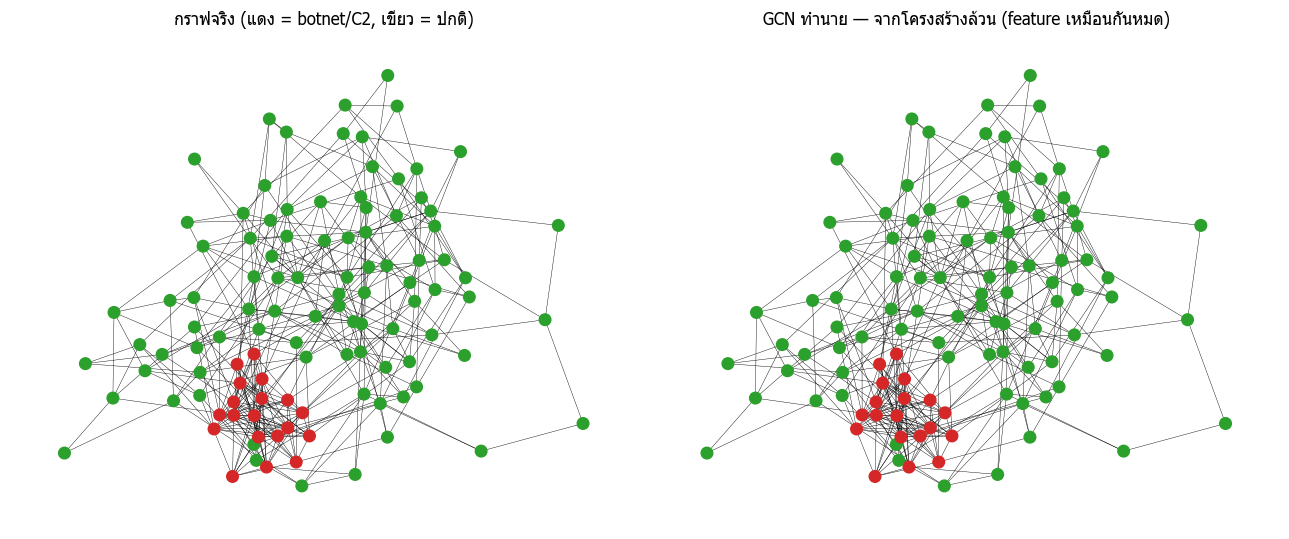

botnet รวมตัวเป็นกระจุกหนาแน่น → GCN จับได้แม้ feature ของทุก node เหมือนกันเป๊ะ
นี่คือสิ่งที่การวิเคราะห์ traffic ทีละ flow (เล่ม 3) มองไม่เห็น — ต้องดู 'ความสัมพันธ์' ทั้งภาพ


In [8]:
# ── เทียบกราฟจริง vs คำทำนายของ GCN ──
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
pos_n = nx.spring_layout(Gn, seed=3)
nx.draw(Gn, pos_n, node_color=["tab:red" if l else "tab:green" for l in y_n],
        node_size=70, width=0.3, ax=ax[0])
ax[0].set_title("กราฟจริง (แดง = botnet/C2, เขียว = ปกติ)")
nx.draw(Gn, pos_n, node_color=["tab:red" if p else "tab:green" for p in pred_n],
        node_size=70, width=0.3, ax=ax[1])
ax[1].set_title("GCN ทำนาย — จากโครงสร้างล้วน (feature เหมือนกันหมด)")
plt.tight_layout(); plt.show()
print("botnet รวมตัวเป็นกระจุกหนาแน่น → GCN จับได้แม้ feature ของทุก node เหมือนกันเป๊ะ")
print("นี่คือสิ่งที่การวิเคราะห์ traffic ทีละ flow (เล่ม 3) มองไม่เห็น — ต้องดู 'ความสัมพันธ์' ทั้งภาพ")

---
## Part 5 — ข้อควรระวัง + ประเภทงานของ GNN

### ⚠️ Over-smoothing — ทำไมซ้อน GNN ลึก ๆ ไม่ได้

สัญชาตญาณบอกว่า "ชั้นเยอะ = มองไกล = ดีกว่า" แต่ GNN กลับตรงข้าม:
ถ้าซ้อนชั้นมากเกินไป ทุก node จะดูดข้อมูลจากเพื่อนบ้านมาเฉลี่ยซ้ำ ๆ จนสุดท้าย **ตัวแทนของทุก node เหมือนกันหมด**
(เหมือนหยดสีในน้ำที่กระจายจนกลมกลืน) — แยกอะไรไม่ออกอีกต่อไป เรียกว่า **over-smoothing**

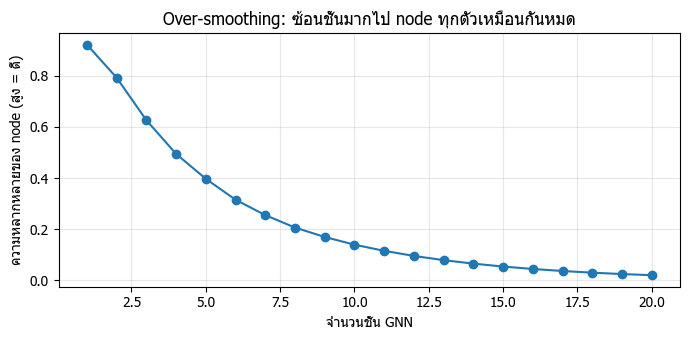

→ ความหลากหลายดิ่งลงเรื่อย ๆ จึงนิยมใช้ GNN แค่ 2–3 ชั้น (อย่างที่เราใช้ใน Part 3–4)


In [9]:
# ── สาธิต over-smoothing: ยิ่งซ้อนชั้น ตัวแทน node ยิ่งเหมือนกันหมด ──
A_hat_k = normalize_adj(A_k)
np.random.seed(0)
H = np.random.randn(A_k.shape[0], 8)                     # feature สุ่มเริ่มต้น

diversity = []
H_cur = H.copy()
for layer in range(1, 21):
    H_cur = A_hat_k @ H_cur                               # message passing ซ้ำ ๆ (ไม่มี weight เพื่อดูผลล้วน)
    # วัด "ความหลากหลาย" = ค่าเฉลี่ยระยะห่างระหว่าง node (ยิ่งต่ำ = ยิ่งเหมือนกัน)
    Hn = H_cur / (np.linalg.norm(H_cur, axis=1, keepdims=True) + 1e-9)
    sim = Hn @ Hn.T
    diversity.append(1 - sim[np.triu_indices(len(Hn), 1)].mean())

plt.figure(figsize=(7, 3.5))
plt.plot(range(1, 21), diversity, "o-")
plt.xlabel("จำนวนชั้น GNN"); plt.ylabel("ความหลากหลายของ node (สูง = ดี)")
plt.title("Over-smoothing: ซ้อนชั้นมากไป node ทุกตัวเหมือนกันหมด")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("→ ความหลากหลายดิ่งลงเรื่อย ๆ จึงนิยมใช้ GNN แค่ 2–3 ชั้น (อย่างที่เราใช้ใน Part 3–4)")

### งานของ GNN มี 3 ระดับ

| ระดับ | ถาม | ตัวอย่าง |
|---|---|---|
| **Node-level** | node นี้คืออะไร? | จำแนกฝ่าย (Part 3), ตรวจ botnet (Part 4), จับบัญชีปลอม |
| **Edge-level** (link prediction) | 2 node นี้*ควร*เชื่อมกันไหม? | แนะนำเพื่อน/สินค้า, ทำนายปฏิสัมพันธ์ยา-โปรตีน |
| **Graph-level** | กราฟ*ทั้งอัน*คืออะไร? | โมเลกุลนี้เป็นพิษไหม, โปรแกรมนี้เป็นมัลแวร์ไหม |

เล่มนี้โฟกัส node-level (พบบ่อยสุด) แต่ทั้ง 3 ใช้ message passing แบบเดียวกันเป็นแกน

---
## Part 6 — ของจริง + สรุปทั้ง 6 เล่ม

### 🌍 GNN ในโลกจริง
- **Google Maps** — ทำนายเวลาเดินทาง (ETA) โดยมองถนนเป็นกราฟ
- **ค้นพบยา / เคมี** — ทำนายคุณสมบัติโมเลกุล (อะตอม=node, พันธะ=edge) เร่งการค้นหายาใหม่
- **ระบบแนะนำ** — Pinterest, Amazon, UberEats ใช้ GNN บนกราฟ user–item ขนาดมหึมา
- **ตรวจจับการฉ้อโกง** — ธนาคาร/บัตรเครดิตจับ "วงจรฉ้อโกง" จากรูปแบบการโอน (แบบเดียวกับ botnet Part 4)
- **เครือข่ายสังคม / security** — ตรวจบัญชีปลอม, จับ coordinated attack, วิเคราะห์ lateral movement

### ⚙️ เครื่องมือจริง
- **PyTorch Geometric (PyG)** และ **DGL** — ไลบรารี GNN ที่มีทุก layer พร้อมใช้ (GCN, GAT, GraphSAGE)
- **GraphSAGE** — เทคนิคสุ่มเพื่อนบ้านให้ scale กับกราฟพันล้าน node ได้
- **GAT (Graph Attention)** — เอา attention (เล่ม 1!) มาถ่วงน้ำหนักเพื่อนบ้านแต่ละตัว

### ⚠️ ความท้าทาย
- **Scalability** — กราฟจริงมี node เป็นพันล้าน เก็บ adjacency ทั้งก้อนไม่ไหว ต้องสุ่ม sub-graph
- **Over-smoothing** (Part 5) — จำกัดความลึกของโมเดล
- **กราฟเปลี่ยนตลอดเวลา** — เพื่อน/การเชื่อมต่อใหม่เกิดตลอด (dynamic graph)

---

### 🎓 สรุปทั้ง 6 เล่ม

| เล่ม | แก่น | โครงสร้างข้อมูล |
|---|---|---|
| 1 — ML Fundamentals | neuron → CNN → attention → mini GPT | เวกเตอร์ / ภาพ / ลำดับ |
| 2 — LLM Deep Dive | tokenizer → pretrain → fine-tune | ลำดับ (ข้อความ) |
| 3 — ML × Network Security | classical ML + unsupervised + adversarial | ตาราง |
| 4 — Reinforcement Learning | Q-learning → DQN → REINFORCE → RLHF | state/action/reward |
| 5 — Generative Vision | VAE → GAN → Diffusion | ภาพ |
| 6 — Graph Neural Networks | message passing → GCN → botnet detection | **กราฟ** |

> ครบทุกโครงสร้างข้อมูลหลักของ ML: เวกเตอร์, ภาพ, ลำดับ, ตาราง, และกราฟ
> ทุกอย่างยังตั้งอยู่บนวงจรเดียวกัน: **forward → loss → backprop → update**
> GNN แค่เพิ่มขั้น "ให้ node คุยกับเพื่อนบ้าน" เข้าไปใน forward — ส่วนที่เหลือเหมือนเดิมหมด

### แหล่งเรียนรู้ต่อ
- 📄 *Semi-Supervised Classification with Graph Convolutional Networks* (Kipf & Welling, 2017) — ต้นตำรับ GCN
- 📚 **PyTorch Geometric** docs + tutorials — ลงมือทำ GNN จริงจัง
- 🎬 Stanford **CS224W: Machine Learning with Graphs** (ฟรีบน YouTube) — คอร์สมาตรฐานของสายนี้
- 📊 **Open Graph Benchmark (OGB)** — dataset กราฟใหญ่ ๆ สำหรับลองของจริง